<a href="https://colab.research.google.com/github/brunogk/Assistente-agricola-RAG/blob/main/assistente_agricola_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌱 Assistente Agrícola com RAG + Dados de Solo

**Projeto de portfólio — Bruno Gomes Kobicz**

Sistema de perguntas e respostas em linguagem natural sobre dados reais de análise de solo, combinando:
- **RAG (Retrieval-Augmented Generation)**: busca os talhões mais relevantes antes de responder
- **OpenAI Embeddings**: transforma dados de solo em vetores semânticos
- **FAISS**: índice de busca vetorial eficiente
- **Text-to-SQL**: traduz perguntas em linguagem natural para queries SQL sobre os dados
- **GPT-4o-mini**: gera respostas agronômicas contextualizadas

---

## ⚙️ Etapa 1 — Instalar dependências

Esta etapa inicial configura o ambiente, instalando todas as bibliotecas Python necessárias para o projeto, como `openai` para interagir com a API da OpenAI, `faiss-cpu` para busca vetorial eficiente, `pandas` para manipulação de dados tabulares e `numpy` para operações numéricas.

In [7]:
!pip install openai faiss-cpu pandas numpy -q
print('✓ Dependências instaladas')

✓ Dependências instaladas


## 🔑 Etapa 2 — Configurar cliente OpenAI

> **Atenção:** Como forma de segurança dos dados, no espaço (🔑 Secrets) foi adicionado uma chave chamada `OPENAI_API_KEY` com uma chave da OpenAI. Lembrete de **Nunca cole a chave diretamente no código**.


Aqui é realizada a configuração do cliente OpenAI. A chave de API é carregada de forma segura usando o gerenciador de segredos do Colab (`userdata.get('OPENAI_API_KEY')`), garantindo que a chave não seja exposta diretamente no código. Em seguida, o cliente da OpenAI é inicializado para permitir chamadas à API.

In [8]:
import openai
import pandas as pd
import numpy as np
import faiss
import json
from google.colab import userdata

client = openai.OpenAI(
    api_key=userdata.get('OPENAI_API_KEY')
)

print('✓ Cliente OpenAI configurado')

✓ Cliente OpenAI configurado


## 🗂️ Etapa 3 — Criar dataset de análise de solo

Dataset sintético baseado em faixas típicas de **Latossolo Vermelho do Paraná**. Em produção, substitua por um CSV real de laudos de laboratório.

Nesta etapa, é criado um dataset sintético de análise de solo, baseado em características típicas de Latossolos Vermelhos do Paraná. Este dataset é armazenado em um DataFrame do Pandas e salvo em um arquivo CSV (`analise_solo.csv`), que servirá como a base de dados para o assistente agronômico. São gerados dados para 8 talhões diferentes, com diversas métricas de fertilidade.

In [9]:
dados_solo = {
    'talhao':         ['T01',    'T02',     'T03',     'T04',          'T05',   'T06',     'T07',    'T08'],
    'municipio':      ['Maringá','Londrina', 'Cascavel','Ponta Grossa', 'Maringá','Umuarama','Maringá','Cascavel'],
    'cultura':        ['Soja',   'Milho',   'Soja',    'Trigo',        'Milho', 'Soja',    'Café',   'Milho'],
    'pH_CaCl2':       [4.8,      5.6,       6.1,       5.2,            4.5,     5.9,       5.4,      6.3],
    'MO_g_dm3':       [28,       35,        22,        41,             18,      30,        45,       26],
    'P_mg_dm3':       [6.2,      18.4,      32.1,      9.8,            4.1,     22.0,      15.3,     28.7],
    'K_cmolc_dm3':    [0.18,     0.42,      0.55,      0.31,           0.12,    0.38,      0.60,     0.47],
    'Ca_cmolc_dm3':   [1.8,      4.2,       5.1,       3.3,            1.2,     4.8,       5.5,      5.8],
    'Mg_cmolc_dm3':   [0.7,      1.6,       2.0,       1.1,            0.4,     1.8,       2.2,      2.1],
    'Al_cmolc_dm3':   [1.2,      0.3,       0.0,       0.8,            1.8,     0.1,       0.4,      0.0],
    'argila_pct':     [55,       48,        62,        38,             51,      44,        58,       65],
    'V_pct':          [38,       62,        71,        52,             30,      68,        65,       74],
    'CTC_cmolc_dm3':  [8.2,      11.4,      13.8,      9.6,            7.1,     12.1,      14.5,     13.9],
    'B_mg_dm3':       [0.12,     0.28,      0.35,      0.19,           0.09,    0.31,      0.42,     0.38],
    'Cu_mg_dm3':      [1.8,      3.2,       2.9,       1.5,            1.1,     2.7,       4.1,      3.0],
    'Zn_mg_dm3':      [0.9,      2.4,       3.8,       1.2,            0.5,     2.1,       5.2,      3.5],
}

df = pd.DataFrame(dados_solo)
df.to_csv('analise_solo.csv', index=False)

print(f'✓ Dataset criado com {len(df)} talhões')
df

✓ Dataset criado com 8 talhões


,talhao,municipio,cultura,pH_CaCl2,MO_g_dm3,P_mg_dm3,K_cmolc_dm3,Ca_cmolc_dm3,Mg_cmolc_dm3,Al_cmolc_dm3,argila_pct,V_pct,CTC_cmolc_dm3,B_mg_dm3,Cu_mg_dm3,Zn_mg_dm3
0,T01,Maringá,Soja,4.8,28,6.2,0.18,1.8,0.7,1.2,55,38,8.2,0.12,1.8,0.9
1,T02,Londrina,Milho,5.6,35,18.4,0.42,4.2,1.6,0.3,48,62,11.4,0.28,3.2,2.4
2,T03,Cascavel,Soja,6.1,22,32.1,0.55,5.1,2.0,0.0,62,71,13.8,0.35,2.9,3.8
3,T04,Ponta Grossa,Trigo,5.2,41,9.8,0.31,3.3,1.1,0.8,38,52,9.6,0.19,1.5,1.2
4,T05,Maringá,Milho,4.5,18,4.1,0.12,1.2,0.4,1.8,51,30,7.1,0.09,1.1,0.5
5,T06,Umuarama,Soja,5.9,30,22.0,0.38,4.8,1.8,0.1,44,68,12.1,0.31,2.7,2.1
6,T07,Maringá,Café,5.4,45,15.3,0.60,5.5,2.2,0.4,58,65,14.5,0.42,4.1,5.2
7,T08,Cascavel,Milho,6.3,26,28.7,0.47,5.8,2.1,0.0,65,74,13.9,0.38,3.0,3.5


## 📝 Etapa 4 — Converter cada talhão em texto para embedding

O RAG funciona com texto, então convertemos cada linha do DataFrame numa descrição textual detalhada do laudo de solo.

Para que o sistema RAG possa processar os dados de solo, cada linha (talhão) do DataFrame é convertida em um texto descritivo detalhado. Essa função `linha_para_texto` transforma os dados numéricos e categóricos de cada talhão em uma string formatada, que será utilizada posteriormente para gerar os embeddings ( Embedding é uma forma inteligente de converter ideias e textos em números para que computadores possam entender e comparar o significado deles.)

In [10]:
def linha_para_texto(row):
    """
    Converte uma linha do DataFrame em texto descritivo do laudo.
    Esse texto é o que vai virar embedding — quanto mais rico, melhor a busca.
    """
    return f"""Talhão {row['talhao']} em {row['municipio']}, cultivando {row['cultura']}.
Análise química: pH CaCl2={row['pH_CaCl2']}, matéria orgânica={row['MO_g_dm3']} g/dm³,
fósforo (P)={row['P_mg_dm3']} mg/dm³, potássio (K)={row['K_cmolc_dm3']} cmolc/dm³,
cálcio (Ca)={row['Ca_cmolc_dm3']} cmolc/dm³, magnésio (Mg)={row['Mg_cmolc_dm3']} cmolc/dm³,
alumínio (Al)={row['Al_cmolc_dm3']} cmolc/dm³.
Textura: argila={row['argila_pct']}%.
Saturação por bases (V%)={row['V_pct']}%, CTC={row['CTC_cmolc_dm3']} cmolc/dm³.
Micronutrientes: B={row['B_mg_dm3']} mg/dm³, Cu={row['Cu_mg_dm3']} mg/dm³, Zn={row['Zn_mg_dm3']} mg/dm³."""

# Aplica a conversão em todos os talhões
documentos = [linha_para_texto(row) for _, row in df.iterrows()]

# Exibe um exemplo
print('Exemplo de documento gerado:')
print('-' * 60)
print(documentos[0])

Exemplo de documento gerado:
------------------------------------------------------------
Talhão T01 em Maringá, cultivando Soja.
Análise química: pH CaCl2=4.8, matéria orgânica=28 g/dm³,
fósforo (P)=6.2 mg/dm³, potássio (K)=0.18 cmolc/dm³,
cálcio (Ca)=1.8 cmolc/dm³, magnésio (Mg)=0.7 cmolc/dm³,
alumínio (Al)=1.2 cmolc/dm³.
Textura: argila=55%.
Saturação por bases (V%)=38%, CTC=8.2 cmolc/dm³.
Micronutrientes: B=0.12 mg/dm³, Cu=1.8 mg/dm³, Zn=0.9 mg/dm³.


## 🔢 Etapa 5 — Gerar embeddings e construir índice FAISS

Embeddings são vetores numéricos que representam o *significado* de cada laudo. O FAISS permite buscar os mais similares à pergunta do usuário em milissegundos.
**FAISS (Facebook AI Similarity Search) é uma biblioteca de código aberto desenvolvida pelo Facebook AI Research para busca eficiente de similaridade e agrupamento de vetores densos. Em termos mais simples, é uma ferramenta extremamente rápida para encontrar os vetores mais parecidos dentro de um conjunto muito grande de vetores**

Nesta etapa crucial, os textos descritivos de cada talhão são transformados em vetores numéricos (embeddings) utilizando a API de embeddings da OpenAI (`text-embedding-3-small`). Esses embeddings capturam o significado semântico dos laudos de solo. Em seguida, é construído um índice FAISS (`IndexFlatIP`) com esses embeddings, permitindo buscas rápidas por similaridade (cosseno) entre os laudos e as perguntas dos usuários.

In [11]:
def gerar_embedding(texto):
    """Chama a API da OpenAI para gerar embedding de um texto."""
    resposta = client.embeddings.create(
        model='text-embedding-3-small',
        input=texto
    )
    return resposta.data[0].embedding

print('Gerando embeddings dos talhões...')
embeddings = [gerar_embedding(doc) for doc in documentos]

# Converte para array numpy (formato necessário pelo FAISS)
matriz_embeddings = np.array(embeddings, dtype='float32')

# Cria índice FAISS (Inner Product = cosine similarity com vetores normalizados)
dimensao = matriz_embeddings.shape[1]
indice = faiss.IndexFlatIP(dimensao)

# Normaliza os vetores antes de adicionar (necessário para busca por cosseno)
faiss.normalize_L2(matriz_embeddings)
indice.add(matriz_embeddings)

print(f'✓ Índice FAISS criado com {indice.ntotal} vetores de dimensão {dimensao}')

Gerando embeddings dos talhões...
✓ Índice FAISS criado com 8 vetores de dimensão 1536


## 🔍 Etapa 6 — Função de busca RAG

O coração do sistema: recebe a pergunta, transforma em embedding, busca os talhões mais relevantes e retorna o contexto para o modelo.

Esta função implementa a parte de *Retrieval* (recuperação) do RAG. Ela recebe uma pergunta do usuário, gera o embedding dessa pergunta e utiliza o índice FAISS para encontrar os `top_k` talhões cujos embeddings são mais similares à pergunta. Os detalhes dos talhões relevantes (incluindo laudos e scores de similaridade) são retornados para serem usados como contexto na geração da resposta.

In [12]:
def buscar_talhoes_relevantes(pergunta, top_k=3):
    """
    Etapa de Retrieval do RAG:
    1. Gera embedding da pergunta
    2. Busca os top_k talhões mais similares no índice FAISS
    3. Retorna os textos dos laudos relevantes
    """
    # Embedding da pergunta
    emb_pergunta = np.array([gerar_embedding(pergunta)], dtype='float32')
    faiss.normalize_L2(emb_pergunta)

    # Busca no índice
    scores, indices = indice.search(emb_pergunta, top_k)

    # Retorna os documentos e seus scores
    resultados = []
    for i, idx in enumerate(indices[0]):
        resultados.append({
            'talhao': df.iloc[idx]['talhao'],
            'municipio': df.iloc[idx]['municipio'],
            'cultura': df.iloc[idx]['cultura'],
            'score': round(float(scores[0][i]), 3),
            'laudo': documentos[idx]
        })

    return resultados


# Teste rápido da busca
teste = buscar_talhoes_relevantes('talhões com pH baixo e necessidade de calagem')
print('Talhões mais relevantes para a busca de teste:')
for r in teste:
    print(f"  → {r['talhao']} ({r['municipio']}) | score: {r['score']}")

Talhões mais relevantes para a busca de teste:
  → T02 (Londrina) | score: 0.569
  → T04 (Ponta Grossa) | score: 0.562
  → T08 (Cascavel) | score: 0.56


## 🤖 Etapa 7 — Função principal do assistente

Etapa de *Generation* do RAG: usa o contexto recuperado + conhecimento agronômico do modelo para gerar uma resposta técnica e prática.

Esta é a função principal do assistente, que integra as etapas de *Retrieval* e *Generation* do RAG. Ela utiliza o `SYSTEM_PROMPT` para instruir o modelo GPT-4o-mini a atuar como um agrônomo especialista. A função `perguntar_ao_assistente` recupera os talhões relevantes, monta um contexto com seus laudos e envia esse contexto, juntamente com a pergunta do usuário, para o modelo gerar uma resposta agronômica contextualizada e prática.

In [13]:
SYSTEM_PROMPT = """
Você é um agrônomo especialista em fertilidade do solo e nutrição de plantas,
com foco em culturas do Centro-Sul do Brasil (soja, milho, trigo, café).

Você recebe laudos de análise de solo de talhões específicos e responde perguntas
do produtor rural com base exclusivamente nesses dados.

Suas respostas devem:
- Ser diretas e práticas, como um consultor de campo
- Citar o número do talhão ao fazer recomendações
- Mencionar os valores encontrados vs faixas ideais quando relevante
- Usar linguagem técnica mas acessível ao produtor
- Indicar quando algum dado está fora de faixa e sugerir ação corretiva
- Se a pergunta não puder ser respondida com os dados disponíveis, dizer claramente

Faixas de referência para solos do Paraná (Latossolo Vermelho):
- pH CaCl2 ideal para soja/milho: 5.5–6.0 | trigo: 5.5–6.5 | café: 5.5–6.0
- V% ideal: 60–70% para a maioria das culturas
- MO adequada: >30 g/dm³
- P adequado (Mehlich): >12 mg/dm³
- K adequado: >0.30 cmolc/dm³
- Al tóxico: >0.5 cmolc/dm³ (exige calagem urgente)
"""


def perguntar_ao_assistente(pergunta, top_k=3, verbose=False):
    """
    Pipeline RAG completo:
    1. Retrieval: busca talhões relevantes
    2. Augmentation: monta contexto com os laudos
    3. Generation: chama o modelo com contexto + pergunta
    """
    # 1. Retrieval
    talhoes = buscar_talhoes_relevantes(pergunta, top_k=top_k)

    if verbose:
        print(f'🔍 Talhões recuperados: {[t["talhao"] for t in talhoes]}')

    # 2. Augmentation — monta o contexto
    contexto = "\n\n".join([
        f"[Laudo — {t['talhao']} | Score de relevância: {t['score']}]\n{t['laudo']}"
        for t in talhoes
    ])

    prompt_usuario = f"""
Dados de análise de solo disponíveis:

{contexto}

---
Pergunta do produtor: {pergunta}
"""

    # 3. Generation
    resposta = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': prompt_usuario}
        ],
        temperature=0.3,  # baixo para respostas mais precisas/técnicas
        max_tokens=800
    )

    return resposta.choices[0].message.content


print('✓ Assistente pronto. Use a célula abaixo para fazer perguntas.')

✓ Assistente pronto. Use a célula abaixo para fazer perguntas.


## 💬 Etapa 8 — Fazer perguntas ao assistente

Aqui são apresentados exemplos de como interagir com o assistente RAG, permitindo ao usuário testar o sistema com diferentes perguntas sobre a fertilidade do solo e as necessidades dos talhões. As células abaixo demonstram a capacidade do assistente em fornecer recomendações baseadas nos dados dos laudos recuperados.

In [14]:
# ✏️ Troque a pergunta abaixo e execute a célula

pergunta = "Quais talhões precisam de calagem urgente e qual a necessidade estimada?"

print(f'Pergunta: {pergunta}')
print('=' * 60)
resposta = perguntar_ao_assistente(pergunta, verbose=True)
print(resposta)

Pergunta: Quais talhões precisam de calagem urgente e qual a necessidade estimada?
🔍 Talhões recuperados: ['T02', 'T08', 'T05']
Com base nos laudos apresentados, o talhão que precisa de calagem urgente é o T05 em Maringá. 

**Talhão T05:**
- pH CaCl2 = 4.5 (fora da faixa ideal para milho, que é 5.5–6.0)
- Alumínio (Al) = 1.8 cmolc/dm³ (acima do limite de toxicidade de 0.5 cmolc/dm³)

**Necessidade de calagem:**
Para elevar o pH do solo para a faixa ideal (5.5), é necessário aplicar calcário. A quantidade de calcário a ser aplicada depende da CTC e do pH atual. Uma estimativa inicial para elevar o pH em 1 unidade em solos com CTC de 7.1 cmolc/dm³ pode variar entre 2 a 4 toneladas de calcário por hectare, dependendo da qualidade do calcário e da eficiência de reação no solo.

Recomendo realizar um cálculo mais preciso considerando a análise de saturação por bases e a necessidade de correção do pH, além de realizar a aplicação o mais breve possível para garantir a saúde das plantas.


In [15]:
pergunta = "O talhão T03 em Cascavel está adequado para soja? O que precisa corrigir?"

print(f'Pergunta: {pergunta}')
print('=' * 60)
print(perguntar_ao_assistente(pergunta))

Pergunta: O talhão T03 em Cascavel está adequado para soja? O que precisa corrigir?
O talhão T03 em Cascavel apresenta os seguintes resultados:

- pH CaCl2: 6.1 (dentro da faixa ideal para soja, que é 5.5–6.0)
- Matéria orgânica: 22 g/dm³ (abaixo do ideal, que é >30 g/dm³)
- Fósforo (P): 32.1 mg/dm³ (acima do ideal, que é >12 mg/dm³)
- Potássio (K): 0.55 cmolc/dm³ (acima do ideal, que é >0.30 cmolc/dm³)
- Alumínio (Al): 0.0 cmolc/dm³ (sem toxicidade)
- V%: 71% (dentro da faixa ideal de 60–70%)
- CTC: 13.8 cmolc/dm³ (adequada para a cultura)

**Recomendações:**
1. **Matéria Orgânica**: É necessário aumentar a matéria orgânica do solo. Recomendo a aplicação de adubos orgânicos, como esterco de curral ou composto, para elevar esse valor.
2. **Manter o pH e os níveis de nutrientes**: O pH e os níveis de P e K estão adequados, portanto, mantenha as práticas de manejo que garantam essa condição.

Com essas correções, o talhão T03 estará mais adequado para o cultivo de soja.


In [16]:
pergunta = "Quais talhões têm deficiência de fósforo e potássio simultaneamente?"

print(f'Pergunta: {pergunta}')
print('=' * 60)
print(perguntar_ao_assistente(pergunta))

Pergunta: Quais talhões têm deficiência de fósforo e potássio simultaneamente?
Analisando os talhões com base nos dados fornecidos:

1. **Talhão T04 (Trigo)**:
   - Fósforo (P): 9.8 mg/dm³ (deficiência, ideal >12 mg/dm³)
   - Potássio (K): 0.31 cmolc/dm³ (adequado, ideal >0.30 cmolc/dm³)

2. **Talhão T02 (Milho)**:
   - Fósforo (P): 18.4 mg/dm³ (adequado)
   - Potássio (K): 0.42 cmolc/dm³ (adequado)

3. **Talhão T03 (Soja)**:
   - Fósforo (P): 32.1 mg/dm³ (adequado)
   - Potássio (K): 0.55 cmolc/dm³ (adequado)

Portanto, **apenas o Talhão T04** apresenta deficiência de fósforo, mas tem potássio adequado. Os outros talhões não apresentam deficiência simultânea de fósforo e potássio. 

Recomendo realizar a correção da deficiência de fósforo no Talhão T04 com a aplicação de fertilizantes fosfatados.


## 🗃️ Etapa 9 — Text-to-SQL: perguntas em linguagem natural geram queries SQL

Diferente do RAG (que busca por similaridade semântica), aqui o modelo:
1. Recebe a pergunta do produtor em português
2. Gera uma query SQL válida sobre a tabela `analise_solo`
3. Executa a query de fato (via SQLite em memória)
4. Interpreta o resultado numérico com linguagem agronômica

Isso é ideal para perguntas **quantitativas e agregadas** (médias, contagens, comparações), que o RAG sozinho não responde bem — o RAG é melhor para perguntas **interpretativas e contextuais**.

Esta seção introduz uma abordagem complementar ao RAG: o *Text-to-SQL*. O objetivo é permitir que o modelo traduza perguntas em linguagem natural para queries SQL, que podem ser executadas em um banco de dados relacional. Isso é particularmente útil para perguntas **quantitativas e agregadas** que o RAG puro não consegue responder com precisão.

In [17]:
import sqlite3

# Cria um banco SQLite em memória e carrega o DataFrame como tabela
conexao = sqlite3.connect(':memory:')
df.to_sql('analise_solo', conexao, index=False, if_exists='replace')

# Captura o schema da tabela para informar o modelo (essencial para Text-to-SQL funcionar bem)
cursor = conexao.cursor()
cursor.execute("PRAGMA table_info(analise_solo)")
schema_colunas = cursor.fetchall()

schema_texto = "\n".join([f"- {col[1]} ({col[2]})" for col in schema_colunas])
print('✓ Banco SQLite criado com a tabela analise_solo')
print('\nSchema da tabela:')
print(schema_texto)

✓ Banco SQLite criado com a tabela analise_solo

Schema da tabela:
- talhao (TEXT)
- municipio (TEXT)
- cultura (TEXT)
- pH_CaCl2 (REAL)
- MO_g_dm3 (INTEGER)
- P_mg_dm3 (REAL)
- K_cmolc_dm3 (REAL)
- Ca_cmolc_dm3 (REAL)
- Mg_cmolc_dm3 (REAL)
- Al_cmolc_dm3 (REAL)
- argila_pct (INTEGER)
- V_pct (INTEGER)
- CTC_cmolc_dm3 (REAL)
- B_mg_dm3 (REAL)
- Cu_mg_dm3 (REAL)
- Zn_mg_dm3 (REAL)


Nesta etapa, o DataFrame de análise de solo é carregado em um banco de dados SQLite em memória, criando uma tabela chamada `analise_solo`. O schema dessa tabela é capturado e formatado em texto, o que é essencial para que o modelo de linguagem possa gerar queries SQL válidas e precisas.

In [18]:
SYSTEM_PROMPT_SQL = f"""
Você é um especialista em SQL que converte perguntas em português sobre dados
agronômicos em queries SQL válidas para SQLite.

A tabela se chama analise_solo e tem as seguintes colunas:
{schema_texto}

Regras obrigatórias:
- Responda APENAS com o código SQL, sem explicações, sem markdown, sem ```sql
- Use somente SELECT — nunca gere INSERT, UPDATE, DELETE ou DROP
- Use nomes de colunas exatamente como informados no schema
- Se a pergunta não puder ser respondida com os dados disponíveis, responda: SELECT 'PERGUNTA_INVALIDA'
"""


def gerar_sql(pergunta):
    """Usa o modelo para traduzir a pergunta em português para uma query SQL."""
    resposta = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT_SQL},
            {'role': 'user', 'content': pergunta}
        ],
        temperature=0  # determinístico — queremos SQL preciso, não criativo
    )
    sql = resposta.choices[0].message.content.strip()
    # Remove markdown caso o modelo insista em incluir
    sql = sql.replace('```sql', '').replace('```', '').strip()
    return sql


def validar_sql_seguro(sql):
    """Camada de segurança: bloqueia qualquer coisa que não seja leitura."""
    sql_lower = sql.lower()
    proibidos = ['insert', 'update', 'delete', 'drop', 'alter', 'create', 'attach']
    if not sql_lower.startswith('select'):
        return False
    if any(p in sql_lower for p in proibidos):
        return False
    return True


def perguntar_com_sql(pergunta, verbose=True):
    """
    Pipeline Text-to-SQL completo:
    1. Gera a query SQL a partir da pergunta
    2. Valida que é uma query segura (somente leitura)
    3. Executa no banco
    4. Interpreta o resultado com linguagem agronômica
    """
    sql = gerar_sql(pergunta)

    if verbose:
        print(f'🗃️  SQL gerado:\n{sql}\n')

    if not validar_sql_seguro(sql):
        return '⚠️ A query gerada não passou na validação de segurança. Tente reformular a pergunta.'

    if 'PERGUNTA_INVALIDA' in sql:
        return 'Não consigo responder essa pergunta com os dados de solo disponíveis.'

    try:
        resultado_df = pd.read_sql_query(sql, conexao)
    except Exception as e:
        return f'⚠️ Erro ao executar a query: {e}'

    if verbose:
        print('📊 Resultado da query:')
        print(resultado_df.to_string(index=False))
        print()

    # Interpretação agronômica do resultado numérico
    interpretacao = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {'role': 'system', 'content': 'Você é um agrônomo que explica resultados de consultas de forma clara e prática para o produtor rural, em poucas frases.'},
            {'role': 'user', 'content': f"Pergunta original: {pergunta}\n\nResultado da consulta:\n{resultado_df.to_string(index=False)}\n\nExplique esse resultado de forma prática."}
        ],
        temperature=0.3
    )

    return interpretacao.choices[0].message.content


print('✓ Pipeline Text-to-SQL pronto.')

✓ Pipeline Text-to-SQL pronto.


Este código define as funções necessárias para o pipeline *Text-to-SQL*. A função `gerar_sql` usa o modelo GPT-4o-mini para traduzir a pergunta do usuário em uma query SQL. A função `validar_sql_seguro` adiciona uma camada de segurança, garantindo que apenas queries de leitura (`SELECT`) sejam executadas. Por fim, `perguntar_com_sql` executa a query gerada, obtém o resultado e usa um segundo prompt para interpretar esse resultado numericamente de forma agronômica e prática para o produtor.

In [19]:
# Testes — perguntas quantitativas que o RAG não responde bem, mas SQL responde com precisão

perguntas_teste = [
    'Qual a média de pH dos talhões de soja?',
    'Quantos talhões têm alumínio acima de 0.5 cmolc/dm³?',
    'Qual talhão tem a maior saturação por bases (V%)?',
    'Qual a diferença entre o pH mais alto e o mais baixo entre os talhões?',
]

for p in perguntas_teste:
    print('=' * 70)
    print(f'❓ {p}')
    print('-' * 70)
    print(perguntar_com_sql(p, verbose=True))
    print()

❓ Qual a média de pH dos talhões de soja?
----------------------------------------------------------------------
🗃️  SQL gerado:
SELECT AVG(pH_CaCl2) FROM analise_solo WHERE cultura = 'soja'

📊 Resultado da query:
AVG(pH_CaCl2)
         None

O resultado "None" indica que não há dados disponíveis sobre o pH dos talhões de soja. Isso pode acontecer se as amostras de solo não foram coletadas ou analisadas. Para obter informações sobre o pH, é importante realizar a coleta de solo e enviar para análise em um laboratório. O pH é fundamental para entender a acidez do solo e como isso pode afetar a produtividade da soja.

❓ Quantos talhões têm alumínio acima de 0.5 cmolc/dm³?
----------------------------------------------------------------------
🗃️  SQL gerado:
SELECT COUNT(*) FROM analise_solo WHERE Al_cmolc_dm3 > 0.5;

📊 Resultado da query:
 COUNT(*)
        3

O resultado indica que existem 3 talhões com níveis de alumínio acima de 0,5 cmolc/dm³. Isso significa que esses talhões podem ter 

Aqui são apresentados exemplos de perguntas quantitativas que são respondidas com sucesso pelo pipeline *Text-to-SQL*. Essas demonstrações mostram como o sistema pode calcular médias, contagens e identificar valores extremos diretamente do banco de dados, interpretando os resultados para o contexto agronômico.

## 🖥️ Etapa 10 — Interface interativa no Colab

Interface simples para demonstrar o projeto sem precisar editar células.

Esta etapa cria uma interface interativa simples usando `ipywidgets`, permitindo ao usuário escolher entre o modo RAG e o modo Text-to-SQL, digitar perguntas ou selecionar exemplos, e ver as respostas diretamente no notebook. Isso torna o projeto mais acessível e fácil de demonstrar sem a necessidade de modificar o código diretamente.

In [20]:
from ipywidgets import widgets, Layout
from IPython.display import display, clear_output

# Perguntas de exemplo — separadas por tipo de pipeline
exemplos_rag = [
    "Quais talhões precisam de calagem urgente?",
    "Qual talhão tem melhor fertilidade para soja?",
    "Talhões com deficiência de fósforo e potássio simultaneamente?",
    "O T03 em Cascavel está pronto para soja?",
    "Algum talhão tem alumínio tóxico?",
]

exemplos_sql = [
    "Qual a média de pH dos talhões de soja?",
    "Quantos talhões têm alumínio acima de 0.5?",
    "Qual talhão tem a maior saturação por bases?",
    "Qual a diferença entre o pH mais alto e o mais baixo?",
]

# Widgets
seletor_modo = widgets.ToggleButtons(
    options=[('🔍 RAG (interpretativo)', 'rag'), ('🗃️ SQL (quantitativo)', 'sql')],
    value='rag',
    style={'button_width': '220px'}
)
input_pergunta = widgets.Text(
    placeholder='Digite sua pergunta sobre os talhões...',
    layout=Layout(width='80%')
)
btn_perguntar = widgets.Button(description='Perguntar', button_style='success')
btn_limpar   = widgets.Button(description='Limpar',    button_style='warning')
dropdown_ex  = widgets.Dropdown(
    options=['— selecione um exemplo —'] + exemplos_rag,
    layout=Layout(width='80%')
)
output       = widgets.Output()

def atualizar_exemplos(change):
    novos = exemplos_rag if seletor_modo.value == 'rag' else exemplos_sql
    dropdown_ex.options = ['— selecione um exemplo —'] + novos

def on_perguntar(b):
    pergunta = input_pergunta.value.strip()
    if not pergunta:
        return
    with output:
        modo = '🔍 RAG' if seletor_modo.value == 'rag' else '🗃️ Text-to-SQL'
        print(f'\n[{modo}] ❓ {pergunta}')
        print('─' * 60)
        if seletor_modo.value == 'rag':
            resp = perguntar_ao_assistente(pergunta)
        else:
            resp = perguntar_com_sql(pergunta, verbose=True)
        print(resp)
        print()
    input_pergunta.value = ''

def on_limpar(b):
    output.clear_output()

def on_exemplo(change):
    if change['new'] != '— selecione um exemplo —':
        input_pergunta.value = change['new']

seletor_modo.observe(atualizar_exemplos, names='value')
btn_perguntar.on_click(on_perguntar)
btn_limpar.on_click(on_limpar)
dropdown_ex.observe(on_exemplo, names='value')

print('🌱 Assistente Agrícola — Análise de Solo')
print('Escolha o modo: RAG para perguntas interpretativas, SQL para perguntas quantitativas.\n')
display(seletor_modo)
display(dropdown_ex)
display(widgets.HBox([input_pergunta, btn_perguntar, btn_limpar]))
display(output)

🌱 Assistente Agrícola — Análise de Solo
Escolha o modo: RAG para perguntas interpretativas, SQL para perguntas quantitativas.



ToggleButtons(options=(('🔍 RAG (interpretativo)', 'rag'), ('🗃️ SQL (quantitativo)', 'sql')), style=ToggleButto…

Dropdown(layout=Layout(width='80%'), options=('— selecione um exemplo —', 'Quais talhões precisam de calagem u…

Output()

## 📊 Etapa 11 — EDA rápido do dataset (para o README do portfólio)

Visualizações que ficam bem no GitHub e demonstram habilidade em análise de dados.

Nesta etapa, são gerados gráficos de Análise Exploratória de Dados (EDA) para visualizar os principais indicadores de fertilidade do solo, como pH, saturação por bases (V%) e a relação entre Fósforo e Potássio. As visualizações utilizam `matplotlib` e `seaborn` e são úteis para apresentar o diagnóstico de fertilidade de forma clara, sendo ideais para inclusão em um README de portfólio.

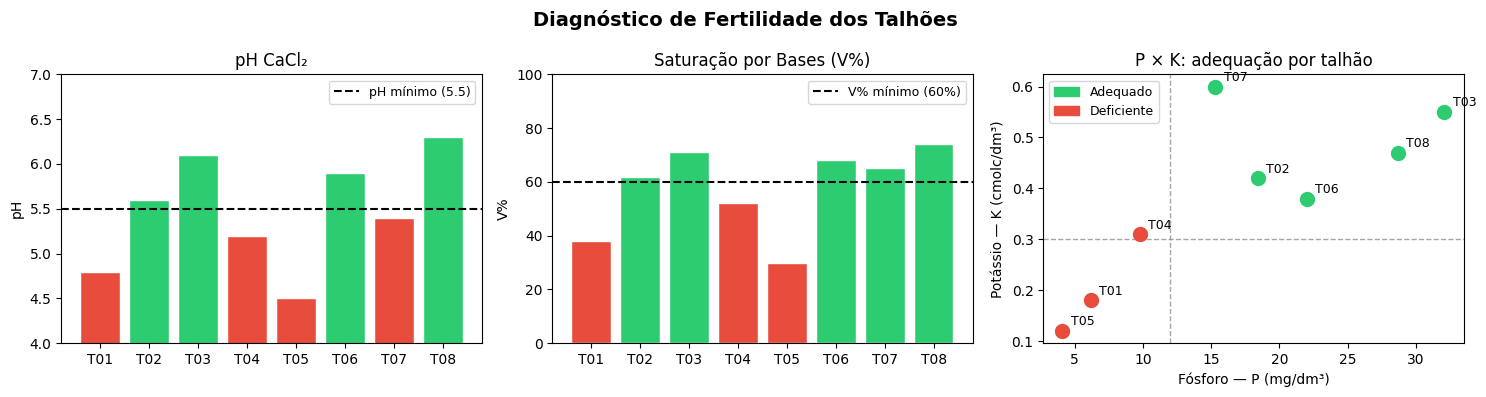

✓ Gráfico salvo como diagnostico_fertilidade.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diagnóstico de Fertilidade dos Talhões', fontsize=14, fontweight='bold')

# 1. pH por talhão com linha de referência
cores_ph = ['#e74c3c' if ph < 5.5 else '#2ecc71' for ph in df['pH_CaCl2']]
axes[0].bar(df['talhao'], df['pH_CaCl2'], color=cores_ph, edgecolor='white')
axes[0].axhline(y=5.5, color='black', linestyle='--', linewidth=1.5, label='pH mínimo (5.5)')
axes[0].set_title('pH CaCl₂')
axes[0].set_ylabel('pH')
axes[0].legend(fontsize=9)
axes[0].set_ylim(4.0, 7.0)

# 2. Saturação por bases (V%) por talhão
cores_v = ['#e74c3c' if v < 60 else '#2ecc71' for v in df['V_pct']]
axes[1].bar(df['talhao'], df['V_pct'], color=cores_v, edgecolor='white')
axes[1].axhline(y=60, color='black', linestyle='--', linewidth=1.5, label='V% mínimo (60%)')
axes[1].set_title('Saturação por Bases (V%)')
axes[1].set_ylabel('V%')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 100)

# 3. Fósforo vs Potássio (scatter)
for _, row in df.iterrows():
    cor = '#2ecc71' if row['P_mg_dm3'] >= 12 and row['K_cmolc_dm3'] >= 0.30 else '#e74c3c'
    axes[2].scatter(row['P_mg_dm3'], row['K_cmolc_dm3'], color=cor, s=100, zorder=3)
    axes[2].annotate(row['talhao'], (row['P_mg_dm3'], row['K_cmolc_dm3']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)

axes[2].axvline(x=12,   color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[2].axhline(y=0.30, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_xlabel('Fósforo — P (mg/dm³)')
axes[2].set_ylabel('Potássio — K (cmolc/dm³)')
axes[2].set_title('P × K: adequação por talhão')
ok_patch    = mpatches.Patch(color='#2ecc71', label='Adequado')
nok_patch   = mpatches.Patch(color='#e74c3c', label='Deficiente')
axes[2].legend(handles=[ok_patch, nok_patch], fontsize=9)

plt.tight_layout()
plt.savefig('diagnostico_fertilidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo como diagnostico_fertilidade.png')

---
## 🚀 Próximos passos para evoluir o projeto

1. **Dados reais**: substituir o dataset sintético por laudos reais de laboratório (EMBRAPA, IAPAR, etc.)
2. **Upload de CSV**: adicionar célula que lê o CSV via `files.upload()` do Colab
3. **Histórico de conversa**: passar as mensagens anteriores para o modelo ter contexto multi-turno
4. **Persistência do índice**: salvar o índice FAISS em disco para não recriar a cada sessão
5. **Roteador inteligente**: usar function calling para o modelo decidir automaticamente entre RAG e SQL, em vez do usuário escolher manualmente
6. **Gradio**: trocar os ipywidgets por uma interface Gradio para deploy público
7. **Novos domínios**: expandir para dados de produtividade, clima (NASA POWER API) e manejo

---
*Projeto desenvolvido por Bruno Gomes Kobicz| Doutorando em Ciências do Solo — UFPR | Portfólio de Dados*

Antes de fazer o upload para plataformas como o GitHub, é recomendável remover metadados de widgets interativos (`ipywidgets`) para evitar possíveis problemas de renderização. Este passo garante que o notebook seja exibido corretamente em visualizadores estáticos.

In [31]:
from google.colab import drive
drive.mount('/content/drive')
import json

# Remove o metadata de widgets que quebra a renderização no GitHub
caminho = '/content/drive/MyDrive/Colab Notebooks/assistente_agricola_rag.ipynb'  # Ajustado para o caminho correto do seu notebook

with open(caminho, 'r', encoding='utf-8') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print('✓ metadata.widgets removido')
else:
    print('Nenhum metadata.widgets encontrado')

with open(caminho, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)

print('✓ Notebook salvo e pronto para subir ao GitHub')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ metadata.widgets removido
✓ Notebook salvo e pronto para subir ao GitHub
